In [4]:
# ── Cell 5: load results (handles both single-file and sharded output) ──────
import glob
import pandas as pd

OUTPUT_CSV = "results_dp_sbm_comparison.csv"   # match OUTPUT_CSV in the driver script

shard_files = sorted(glob.glob(f"{OUTPUT_CSV}.shard*"))
if shard_files:
    df = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
    print(f"Loaded {len(shard_files)} shard files, {len(df)} rows total.")
else:
    df = pd.read_csv(OUTPUT_CSV)
    print(f"Loaded {OUTPUT_CSV}, {len(df)} rows.")

df.head()

Loaded results_dp_sbm_comparison.csv, 632 rows.


,N,sigma,epsilon,rep,method,epsilon_gamma,epsilon_beta,epsilon_rho,delta,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11
0,100,0.5,75.261074,0,edge_flip_vem,NaN,NaN,NaN,0.00001,0.2,0.02,0.2,0.203265,0.017200,0.217959
1,100,0.5,75.261074,0,sbm_dpsgd_all_noised,70.772185,12.423129,1.033895,0.00001,0.2,0.02,0.2,0.152330,0.125008,0.188686
2,100,0.5,75.261074,1,edge_flip_vem,NaN,NaN,NaN,0.00001,0.2,0.02,0.2,0.200816,0.026400,0.194286
3,100,0.5,75.261074,1,sbm_dpsgd_all_noised,70.772185,12.423129,1.033895,0.00001,0.2,0.02,0.2,0.147660,0.120537,0.195843
4,100,0.5,75.261074,2,edge_flip_vem,NaN,NaN,NaN,0.00001,0.2,0.02,0.2,0.213061,0.016400,0.202449


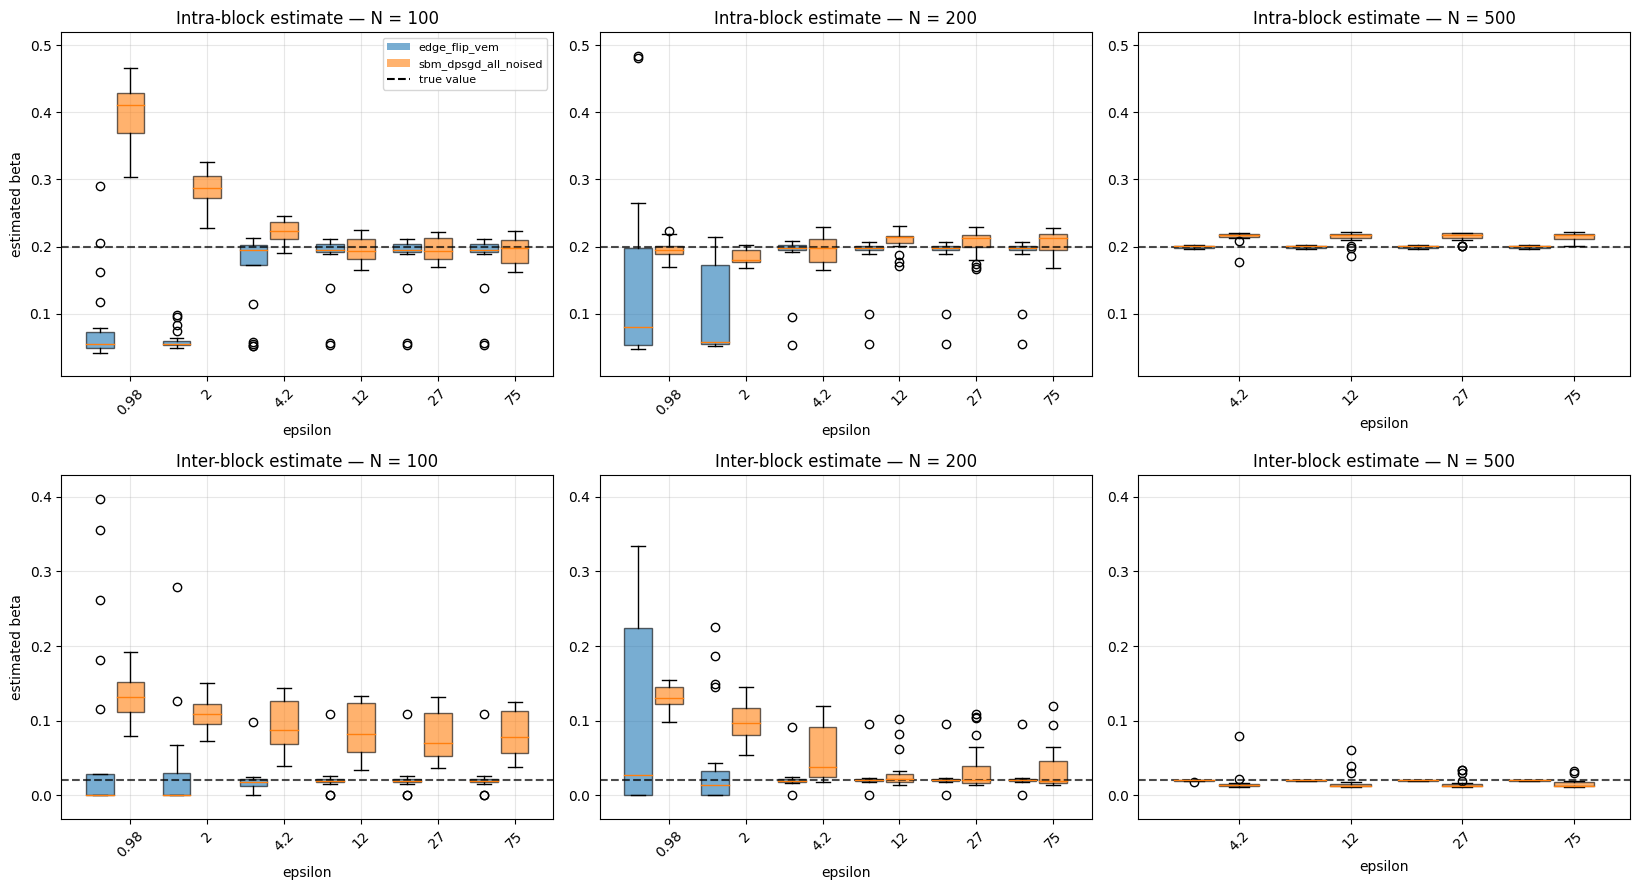

In [5]:
# ── Cell 6 (extensible grid layout): Boxplots of estimated beta vs epsilon ──
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

Ns = sorted(df["N"].unique())
methods = sorted(df["method"].unique())
colors = plt.cm.tab10.colors

MAX_COLS = 3
n_cols = min(MAX_COLS, len(Ns))
n_n_rows = math.ceil(len(Ns) / n_cols)

fig, axes = plt.subplots(
    n_n_rows * 2, n_cols,
    figsize=(5.5 * n_cols, 4.5 * n_n_rows * 2),
    squeeze=False,
)

# ── precompute global y-limits for intra and inter panels separately ────────
df_intra_est = df[["beta_est_00", "beta_est_11"]].mean(axis=1)
intra_ymin, intra_ymax = df_intra_est.min(), df_intra_est.max()
inter_ymin, inter_ymax = df["beta_est_01"].min(), df["beta_est_01"].max()

intra_true_vals = df["beta_true_00"].unique()
inter_true_vals = df["beta_true_01"].unique()
intra_ymin = min(intra_ymin, intra_true_vals.min())
intra_ymax = max(intra_ymax, intra_true_vals.max())
inter_ymin = min(inter_ymin, inter_true_vals.min())
inter_ymax = max(inter_ymax, inter_true_vals.max())

def pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

intra_ylim = pad(intra_ymin, intra_ymax)
inter_ylim = pad(inter_ymin, inter_ymax)

for n_idx, N in enumerate(Ns):
    grid_row = n_idx // n_cols
    grid_col = n_idx % n_cols

    sub = df[df["N"] == N].copy()
    true_00 = sub["beta_true_00"].iloc[0]
    true_01 = sub["beta_true_01"].iloc[0]
    sub["intra_est"] = sub[["beta_est_00", "beta_est_11"]].mean(axis=1)

    eps_vals = sorted(sub["epsilon"].unique())
    width = 0.8 / len(methods)

    for sub_row, (est_col, true_val, row_title, ylim) in enumerate([
        ("intra_est", true_00, "Intra-block estimate", intra_ylim),
        ("beta_est_01", true_01, "Inter-block estimate", inter_ylim),
    ]):
        ax = axes[grid_row * 2 + sub_row, grid_col]
        data, positions = [], []

        for e_idx, eps in enumerate(eps_vals):
            for m_idx, method in enumerate(methods):
                vals = sub[(sub["epsilon"] == eps) & (sub["method"] == method)][est_col]
                if len(vals) == 0:
                    continue
                data.append(vals.values)
                positions.append(e_idx + (m_idx - len(methods) / 2) * width)

        bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
        for patch, i in zip(bp["boxes"], range(len(data))):
            method_idx = i % len(methods)
            patch.set_facecolor(colors[method_idx % len(colors)])
            patch.set_alpha(0.6)

        ax.axhline(true_val, color="black", linestyle="--", alpha=0.7, linewidth=1.5)

        ax.set_ylim(ylim)
        ax.set_xticks(range(len(eps_vals)))
        ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
        ax.set_title(f"{row_title} — N = {N}")
        ax.set_xlabel("epsilon")
        ax.grid(alpha=0.3)

used_grid_positions = {(n_idx // n_cols, n_idx % n_cols) for n_idx in range(len(Ns))}
for grid_row in range(n_n_rows):
    for grid_col in range(n_cols):
        if (grid_row, grid_col) not in used_grid_positions:
            axes[grid_row * 2, grid_col].axis("off")
            axes[grid_row * 2 + 1, grid_col].axis("off")

for r in range(n_n_rows * 2):
    axes[r, 0].set_ylabel("estimated beta")

legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m) for i, m in enumerate(methods)]
legend_elems.append(Line2D([0], [0], color="black", linestyle="--", label="true value"))
axes[0, 0].legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.show()